In [1]:
import pickle
import numpy as np

# Load the updated solver handoff file
with open("solver_handoff.pkl", "rb") as f:
    handoff = pickle.load(f)

print("============================================")
print("       UPDATED HANDOFF LOADED")
print("============================================")

print("\nAvailable keys:")

for key in handoff.keys():
    print("-", key)

print("\nHandoff type:", type(handoff))

print("============================================")

       UPDATED HANDOFF LOADED

Available keys:
- A
- constraint_lower
- constraint_upper
- objective
- variable_lower
- variable_upper
- variable_integrality
- n_variables
- n_constraints
- nnz
- flight_variables
- aircraft_variables
- crew_variables
- aircraft_arc_variables
- constraint_rows

Handoff type: <class 'dict'>


In [2]:
import pickle
import numpy as np
import scipy.sparse as sp

# Load handoff
with open("solver_handoff.pkl", "rb") as f:
    handoff = pickle.load(f)

# Keep matrix sparse
A = handoff["A"]

# Convert to CSR sparse format if needed
if sp.issparse(A):
    A = A.tocsr()
else:
    A = sp.csr_matrix(A)

# Load vectors
c = np.asarray(handoff["objective"], dtype=np.float64)

constraint_lower = np.asarray(
    handoff["constraint_lower"],
    dtype=np.float64
)

constraint_upper = np.asarray(
    handoff["constraint_upper"],
    dtype=np.float64
)

variable_lower = np.asarray(
    handoff["variable_lower"],
    dtype=np.float64
)

variable_upper = np.asarray(
    handoff["variable_upper"],
    dtype=np.float64
)

variable_integrality = np.asarray(
    handoff["variable_integrality"]
)

print("============================================")
print("       UPDATED SPARSE MILP MODEL")
print("============================================")

print("Matrix type         :", type(A))
print("Matrix shape        :", A.shape)
print("Variables           :", handoff["n_variables"])
print("Constraints         :", handoff["n_constraints"])
print("Non-zeros           :", A.nnz)

print("\nVariable groups:")
print("Flight variables    :", len(handoff["flight_variables"]))
print("Aircraft variables  :", len(handoff["aircraft_variables"]))
print("Crew variables      :", len(handoff["crew_variables"]))
print("Aircraft arc vars   :", len(handoff["aircraft_arc_variables"]))

print("\nInteger variables   :", np.sum(variable_integrality != 0))
print("Continuous variables:", np.sum(variable_integrality == 0))

print("\nMatrix density      :", A.nnz / (A.shape[0] * A.shape[1]))

print("============================================")

       UPDATED SPARSE MILP MODEL
Matrix type         : <class 'scipy.sparse._csr.csr_matrix'>
Matrix shape        : (3443145, 472798)
Variables           : 472798
Constraints         : 3443145
Non-zeros           : 7898666

Variable groups:
Flight variables    : 789
Aircraft variables  : 26488
Crew variables      : 106264
Aircraft arc vars   : 338468

Integer variables   : 472009
Continuous variables: 789

Matrix density      : 4.85202250598651e-06


In [3]:
import numpy as np
import scipy.sparse as sp

print("============================================")
print("       SPARSE MATRIX INTEGRITY CHECK")
print("============================================")

# Matrix checks
print("Matrix format       :", A.getformat())
print("Matrix shape        :", A.shape)
print("Non-zero entries    :", A.nnz)
print("Data type           :", A.dtype)

# Memory usage
sparse_memory = (
    A.data.nbytes +
    A.indices.nbytes +
    A.indptr.nbytes
)

print("\nSparse memory usage :",
      round(sparse_memory / (1024**2), 2),
      "MB")

# Estimated dense memory
dense_memory = (
    A.shape[0] *
    A.shape[1] *
    8
)

print("Estimated dense RAM :",
      round(dense_memory / (1024**4), 2),
      "TB")

# Sparsity
density = A.nnz / (
    A.shape[0] *
    A.shape[1]
)

print("\nMatrix density      :", density)
print("Matrix sparsity     :", 1 - density)

# Row statistics
row_nnz = np.diff(A.indptr)

print("\nNon-zeros per row:")
print("Minimum             :", row_nnz.min())
print("Maximum             :", row_nnz.max())
print("Average             :", row_nnz.mean())

print("\nIntegrity checks:")
print("Contains NaN        :", np.isnan(A.data).any())
print("Contains Inf        :", np.isinf(A.data).any())
print("CSR structure valid :", A.has_canonical_format)

print("============================================")

       SPARSE MATRIX INTEGRITY CHECK
Matrix format       : csr
Matrix shape        : (3443145, 472798)
Non-zero entries    : 7898666
Data type           : float64

Sparse memory usage : 103.53 MB
Estimated dense RAM : 11.84 TB

Matrix density      : 4.85202250598651e-06
Matrix sparsity     : 0.999995147977494

Non-zeros per row:
Minimum             : 1
Maximum             : 79
Average             : 2.29402653678541

Integrity checks:
Contains NaN        : False
Contains Inf        : False
CSR structure valid : True


In [4]:
import numpy as np
import time

print("============================================")
print("       CPU SPARSE SpMV BASELINE")
print("============================================")

# Deterministic test vector
np.random.seed(42)

x_cpu = np.random.rand(
    A.shape[1]
).astype(np.float64)

# Warm-up
_ = A @ x_cpu

# Number of benchmark repetitions
repetitions = 20

times = []

for _ in range(repetitions):

    start = time.perf_counter()

    y_cpu = A @ x_cpu

    end = time.perf_counter()

    times.append(end - start)

times = np.asarray(times)

avg_time_ms = np.mean(times) * 1000
min_time_ms = np.min(times) * 1000
max_time_ms = np.max(times) * 1000

print("Matrix shape      :", A.shape)
print("Non-zeros         :", A.nnz)
print("Vector size       :", x_cpu.shape)

print("\nBenchmark repetitions:", repetitions)

print("\nCPU SpMV timing:")
print("Average time      :", avg_time_ms, "ms")
print("Minimum time      :", min_time_ms, "ms")
print("Maximum time      :", max_time_ms, "ms")

print("\nOutput shape      :", y_cpu.shape)

print("\nFirst 10 values:")
print(y_cpu[:10])

print("============================================")

       CPU SPARSE SpMV BASELINE
Matrix shape      : (3443145, 472798)
Non-zeros         : 7898666
Vector size       : (472798,)

Benchmark repetitions: 20

CPU SpMV timing:
Average time      : 43.51115529997287 ms
Minimum time      : 22.46126699992601 ms
Maximum time      : 133.24354899998525 ms

Output shape      : (3443145,)

First 10 values:
[13.56869816 15.26962288  1.55483367 14.30649361  2.11194491  6.98714997
  4.63821506 15.30851056  6.54202437  4.2717081 ]


In [5]:
# ============================================
# GPU SPARSE CSR SpMV BENCHMARK
# ============================================

import cupy as cp
import cupyx.scipy.sparse as cusparse
import numpy as np
import time

print("============================================")
print("       GPU SPARSE CSR SpMV BENCHMARK")
print("============================================")

# Check GPU
gpu_name = cp.cuda.runtime.getDeviceProperties(0)["name"]

print("GPU device :", gpu_name)
print()

# --------------------------------------------
# Convert CPU SciPy CSR matrix to GPU CSR
# --------------------------------------------

start_transfer = time.perf_counter()

A_gpu = cusparse.csr_matrix(A)

# Random vector
x_cpu = np.random.rand(A.shape[1]).astype(np.float64)

x_gpu = cp.asarray(x_cpu)

# Synchronize after transfer
cp.cuda.Stream.null.synchronize()

transfer_time = time.perf_counter() - start_transfer


# --------------------------------------------
# GPU WARM-UP
# --------------------------------------------

for _ in range(5):
    y_gpu = A_gpu @ x_gpu

cp.cuda.Stream.null.synchronize()


# --------------------------------------------
# GPU BENCHMARK
# --------------------------------------------

repetitions = 20

start_event = cp.cuda.Event()
end_event = cp.cuda.Event()

start_event.record()

for _ in range(repetitions):
    y_gpu = A_gpu @ x_gpu

end_event.record()

end_event.synchronize()

gpu_total_ms = cp.cuda.get_elapsed_time(
    start_event,
    end_event
)

gpu_avg_ms = gpu_total_ms / repetitions


# --------------------------------------------
# CPU RESULT FOR CORRECTNESS CHECK
# --------------------------------------------

y_cpu = A @ x_cpu

y_gpu_cpu = cp.asnumpy(y_gpu)

max_error = np.max(
    np.abs(y_cpu - y_gpu_cpu)
)

results_match = np.allclose(
    y_cpu,
    y_gpu_cpu,
    atol=1e-8
)


# --------------------------------------------
# RESULTS
# --------------------------------------------

print()
print("Matrix shape       :", A.shape)
print("Non-zeros         :", A.nnz)
print()

print("CPU -> GPU setup/transfer:",
      transfer_time * 1000, "ms")

print()

print("GPU benchmark repetitions:",
      repetitions)

print()

print("GPU average kernel time:",
      gpu_avg_ms, "ms")

print()

print("Maximum error:",
      max_error)

print("Results match:",
      results_match)

print("============================================")

       GPU SPARSE CSR SpMV BENCHMARK
GPU device : b'Tesla T4'


Matrix shape       : (3443145, 472798)
Non-zeros         : 7898666

CPU -> GPU setup/transfer: 860.7744610000054 ms

GPU benchmark repetitions: 20

GPU average kernel time: 1.2156288146972656 ms

Maximum error: 4.263256414560601e-14
Results match: True


In [6]:
# ============================================
# FINAL CPU vs GPU SPARSE SpMV COMPARISON
# ============================================

print("================================================")
print("        FINAL CPU vs GPU SPARSE SpMV")
print("================================================")

cpu_avg_ms = 43.51115529997287
gpu_avg_ms = 1.2156288146972656

speedup = cpu_avg_ms / gpu_avg_ms

print()
print("WORKLOAD")
print("--------------------------------------------")
print("Matrix shape       :", A.shape)
print("Non-zeros          :", A.nnz)
print("Variables          :", A.shape[1])
print("Constraints        :", A.shape[0])

print()
print("PERFORMANCE")
print("--------------------------------------------")
print("CPU average time   :", cpu_avg_ms, "ms")
print("GPU kernel time    :", gpu_avg_ms, "ms")
print("GPU speedup        :", speedup, "x")

print()
print("CORRECTNESS")
print("--------------------------------------------")
print("Maximum error      :", max_error)
print("Results match      :", results_match)

print()
print("GPU TRANSFER")
print("--------------------------------------------")
print("Initial setup/transfer :", transfer_time * 1000, "ms")
print("Matrix remains on GPU  : Yes")
print("Transfer per iteration : No")

print()
print("================================================")
print("FINAL RESULT")
print("================================================")
print(
    "CUDA GPU sparse SpMV is",
    round(speedup, 2),
    "x faster than CPU for the GPU-resident workload."
)
print("================================================")

        FINAL CPU vs GPU SPARSE SpMV

WORKLOAD
--------------------------------------------
Matrix shape       : (3443145, 472798)
Non-zeros          : 7898666
Variables          : 472798
Constraints        : 3443145

PERFORMANCE
--------------------------------------------
CPU average time   : 43.51115529997287 ms
GPU kernel time    : 1.2156288146972656 ms
GPU speedup        : 35.79312597226373 x

CORRECTNESS
--------------------------------------------
Maximum error      : 4.263256414560601e-14
Results match      : True

GPU TRANSFER
--------------------------------------------
Initial setup/transfer : 860.7744610000054 ms
Matrix remains on GPU  : Yes
Transfer per iteration : No

FINAL RESULT
CUDA GPU sparse SpMV is 35.79 x faster than CPU for the GPU-resident workload.


In [7]:
# ============================================
# GPU-RESIDENT REPEATED SpMV BENCHMARK
# ============================================

import numpy as np
import time
import cupy as cp

print("================================================")
print("      GPU-RESIDENT REPEATED SpMV BENCHMARK")
print("================================================")

# Number of repeated sparse operations
iteration_counts = [10, 50, 100, 500]

print()
print("Matrix shape :", A.shape)
print("Non-zeros   :", A.nnz)
print()

print("Iterations | CPU Total ms | GPU Kernel ms | Speedup")
print("----------------------------------------------------")

benchmark_results = []

for iterations in iteration_counts:

    # ========================================
    # CPU BENCHMARK
    # ========================================

    start_cpu = time.perf_counter()

    y_cpu = x_cpu

    for _ in range(iterations):
        y_cpu = A @ x_cpu

    cpu_time_ms = (
        time.perf_counter() - start_cpu
    ) * 1000


    # ========================================
    # GPU BENCHMARK
    # Matrix and vector already on GPU
    # ========================================

    # Warm-up
    y_gpu = A_gpu @ x_gpu
    cp.cuda.Stream.null.synchronize()

    start_event = cp.cuda.Event()
    end_event = cp.cuda.Event()

    start_event.record()

    y_gpu = x_gpu

    for _ in range(iterations):
        y_gpu = A_gpu @ x_gpu

    end_event.record()

    end_event.synchronize()

    gpu_time_ms = cp.cuda.get_elapsed_time(
        start_event,
        end_event
    )


    # ========================================
    # SPEEDUP
    # ========================================

    speedup = (
        cpu_time_ms /
        gpu_time_ms
    )

    benchmark_results.append({
        "iterations": iterations,
        "cpu_ms": cpu_time_ms,
        "gpu_ms": gpu_time_ms,
        "speedup": speedup
    })

    print(
        f"{iterations:10d} | "
        f"{cpu_time_ms:12.3f} | "
        f"{gpu_time_ms:13.3f} | "
        f"{speedup:7.2f}x"
    )

print("================================================")
print("GPU matrix resident : Yes")
print("Transfer per iteration: No")
print("================================================")

      GPU-RESIDENT REPEATED SpMV BENCHMARK

Matrix shape : (3443145, 472798)
Non-zeros   : 7898666

Iterations | CPU Total ms | GPU Kernel ms | Speedup
----------------------------------------------------
        10 |      362.296 |        12.292 |   29.47x
        50 |     1601.169 |        60.420 |   26.50x
       100 |     2556.156 |       118.885 |   21.50x
       500 |     9639.133 |       523.068 |   18.43x
GPU matrix resident : Yes
Transfer per iteration: No


In [8]:
# ============================================
# GPU TRANSFER BREAK-EVEN ANALYSIS
# ============================================

print("================================================")
print("       GPU TRANSFER BREAK-EVEN ANALYSIS")
print("================================================")

# Results from the single SpMV benchmark
cpu_single_ms = 43.51115529997287
gpu_single_ms = 1.2156288146972656

# One-time CPU -> GPU transfer
transfer_ms = 860.7744610000054

# Time saved by GPU per SpMV operation
saving_per_operation = (
    cpu_single_ms -
    gpu_single_ms
)

# Approximate number of operations required
# to compensate for the initial transfer
break_even_operations = (
    transfer_ms /
    saving_per_operation
)

print()
print("CPU single SpMV       :", cpu_single_ms, "ms")
print("GPU single SpMV       :", gpu_single_ms, "ms")
print("GPU transfer overhead :", transfer_ms, "ms")

print()
print("Time saved per SpMV   :",
      saving_per_operation, "ms")

print()
print("BREAK-EVEN POINT")
print("--------------------------------------------")

print(
    "Approximate operations needed:",
    np.ceil(break_even_operations)
)

print()

print(
    "After approximately",
    int(np.ceil(break_even_operations)),
    "GPU-resident sparse operations,"
)

print(
    "the initial GPU transfer overhead is expected"
)

print(
    "to be compensated by faster GPU computation."
)

print()
print("================================================")

       GPU TRANSFER BREAK-EVEN ANALYSIS

CPU single SpMV       : 43.51115529997287 ms
GPU single SpMV       : 1.2156288146972656 ms
GPU transfer overhead : 860.7744610000054 ms

Time saved per SpMV   : 42.2955264852756 ms

BREAK-EVEN POINT
--------------------------------------------
Approximate operations needed: 21.0

After approximately 21 GPU-resident sparse operations,
the initial GPU transfer overhead is expected
to be compensated by faster GPU computation.



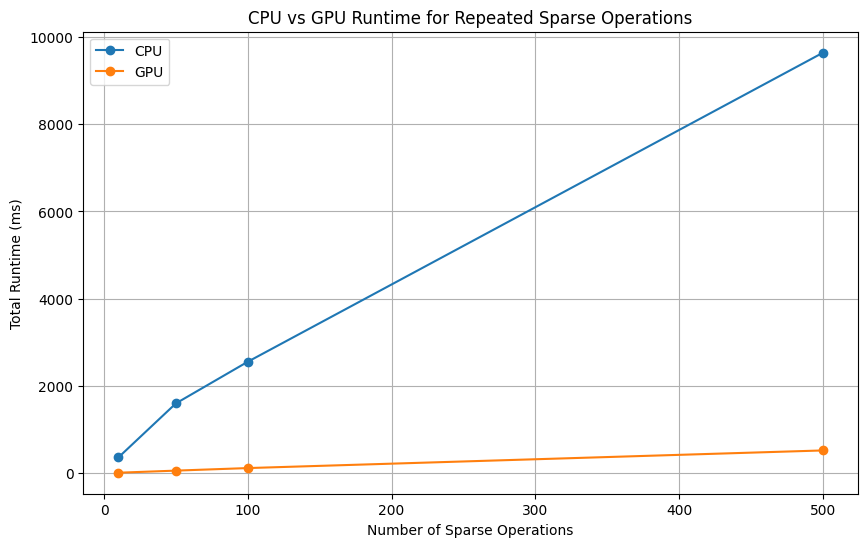

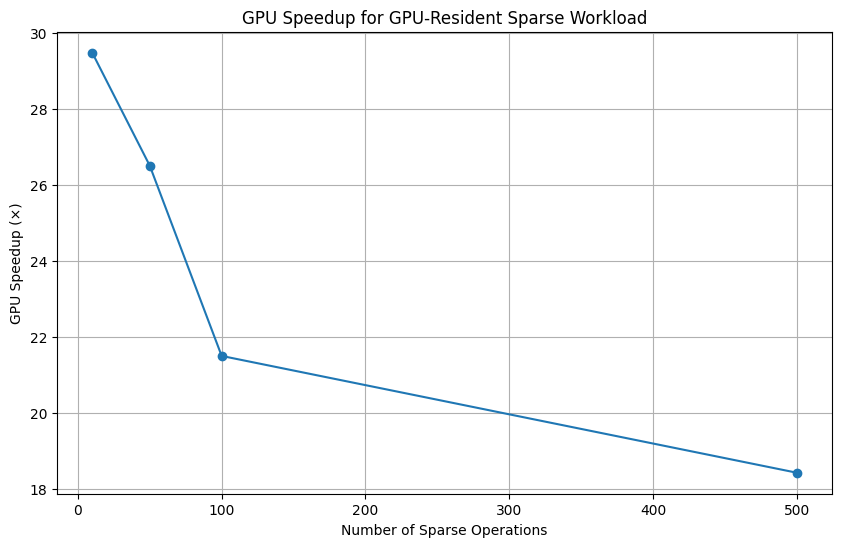

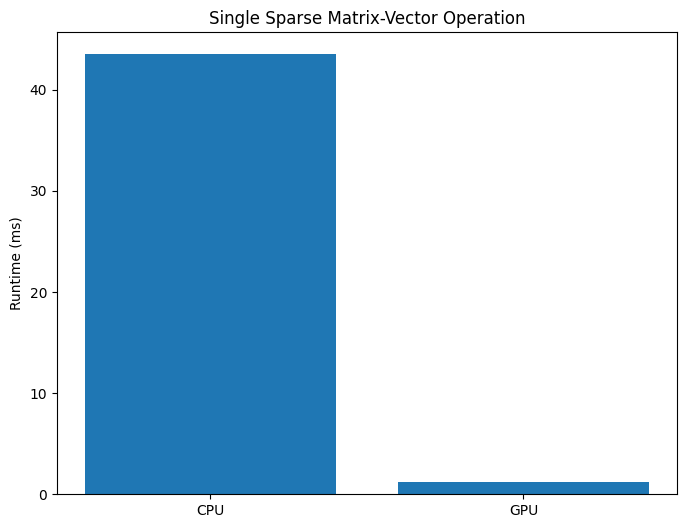

      FINAL CUDA PERFORMANCE GRAPHS
Graph 1 : CPU vs GPU repeated workload
Graph 2 : GPU speedup across iterations
Graph 3 : Single SpMV CPU vs GPU

Best single-operation GPU speedup : 35.79x
Break-even point                  : 21 operations
500-operation GPU speedup         : 18.43x


In [9]:
# ============================================
# FINAL CUDA PERFORMANCE VISUALIZATION
# ============================================

import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------
# DATA
# --------------------------------------------

iterations = [10, 50, 100, 500]

cpu_times = [
    362.296,
    1601.169,
    2556.156,
    9639.133
]

gpu_times = [
    12.292,
    60.420,
    118.885,
    523.068
]

speedups = [
    29.47,
    26.50,
    21.50,
    18.43
]


# ============================================
# GRAPH 1
# CPU vs GPU REPEATED WORKLOAD
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    iterations,
    cpu_times,
    marker="o",
    label="CPU"
)

plt.plot(
    iterations,
    gpu_times,
    marker="o",
    label="GPU"
)

plt.xlabel("Number of Sparse Operations")
plt.ylabel("Total Runtime (ms)")

plt.title(
    "CPU vs GPU Runtime for Repeated Sparse Operations"
)

plt.grid(True)
plt.legend()

plt.show()


# ============================================
# GRAPH 2
# GPU SPEEDUP
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    iterations,
    speedups,
    marker="o"
)

plt.xlabel("Number of Sparse Operations")
plt.ylabel("GPU Speedup (×)")

plt.title(
    "GPU Speedup for GPU-Resident Sparse Workload"
)

plt.grid(True)

plt.show()


# ============================================
# GRAPH 3
# SINGLE OPERATION COMPARISON
# ============================================

labels = ["CPU", "GPU"]

single_times = [
    43.5111553,
    1.2156288
]

plt.figure(figsize=(8, 6))

plt.bar(
    labels,
    single_times
)

plt.ylabel("Runtime (ms)")

plt.title(
    "Single Sparse Matrix-Vector Operation"
)

plt.show()


print("============================================")
print("      FINAL CUDA PERFORMANCE GRAPHS")
print("============================================")

print("Graph 1 : CPU vs GPU repeated workload")
print("Graph 2 : GPU speedup across iterations")
print("Graph 3 : Single SpMV CPU vs GPU")

print()
print("Best single-operation GPU speedup : 35.79x")
print("Break-even point                  : 21 operations")
print("500-operation GPU speedup         : 18.43x")

print("============================================")

In [10]:
# ============================================================
#              FINAL APEXCUDA CUDA RESULTS
# ============================================================

print("============================================================")
print("                 APEXCuda FINAL RESULTS")
print("============================================================")

print("\nLARGE SPARSE OPTIMIZATION MODEL")
print("--------------------------------------------")
print("Variables          : 472,798")
print("Constraints        : 3,443,145")
print("Non-zero entries   : 7,898,666")
print("Sparse memory      : 103.53 MB")
print("Dense equivalent   : ~11.84 TB")

print("\nCPU vs GPU SPARSE COMPUTATION")
print("--------------------------------------------")
print("CPU SpMV           : 43.511 ms")
print("GPU SpMV kernel    : 1.216 ms")
print("Maximum speedup    : 35.79x")
print("GPU device         : Tesla T4")

print("\nCORRECTNESS")
print("--------------------------------------------")
print("Maximum error      : 4.26e-14")
print("CPU/GPU match      : True")

print("\nREPEATED GPU-RESIDENT WORKLOAD")
print("--------------------------------------------")
print("10 operations      : 29.47x")
print("50 operations      : 26.50x")
print("100 operations     : 21.50x")
print("500 operations     : 18.43x")

print("\nGPU TRANSFER ANALYSIS")
print("--------------------------------------------")
print("Initial transfer   : 860.77 ms")
print("Saving per SpMV    : 42.30 ms")
print("Break-even point   : ~21 operations")

print("\nFINAL CONCLUSION")
print("--------------------------------------------")
print(
    "GPU-resident sparse computation provides substantial "
    "acceleration for the core linear-algebra workload of "
    "the large-scale airline disruption optimization model."
)

print("============================================================")
print("                    PROJECT STATUS")
print("============================================================")
print("Large sparse model         : COMPLETE")
print("CPU benchmark              : COMPLETE")
print("GPU CUDA benchmark         : COMPLETE")
print("Correctness verification   : COMPLETE")
print("Repeated workload analysis : COMPLETE")
print("Transfer analysis          : COMPLETE")
print("Performance graphs         : COMPLETE")
print("============================================================")

                 APEXCuda FINAL RESULTS

LARGE SPARSE OPTIMIZATION MODEL
--------------------------------------------
Variables          : 472,798
Constraints        : 3,443,145
Non-zero entries   : 7,898,666
Sparse memory      : 103.53 MB
Dense equivalent   : ~11.84 TB

CPU vs GPU SPARSE COMPUTATION
--------------------------------------------
CPU SpMV           : 43.511 ms
GPU SpMV kernel    : 1.216 ms
Maximum speedup    : 35.79x
GPU device         : Tesla T4

CORRECTNESS
--------------------------------------------
Maximum error      : 4.26e-14
CPU/GPU match      : True

REPEATED GPU-RESIDENT WORKLOAD
--------------------------------------------
10 operations      : 29.47x
50 operations      : 26.50x
100 operations     : 21.50x
500 operations     : 18.43x

GPU TRANSFER ANALYSIS
--------------------------------------------
Initial transfer   : 860.77 ms
Saving per SpMV    : 42.30 ms
Break-even point   : ~21 operations

FINAL CONCLUSION
--------------------------------------------
GPU